In [1]:
train_dir = "D:/Program/dogs-vs-cats/train"
test_dir = "D:/Program/dogs-vs-cats/test1"

In [3]:
import os 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [4]:
imgs_name = os.listdir(train_dir)

imgs_path = []
labels_data = []

for name in imgs_name:
    if name[:3] == "dog":
        label = 0
    if name[:3] == "cat":
        label = 1
    img_path = os.path.join(train_dir,name)
    imgs_path.append(img_path)
    labels_data.append(label)
print(labels_data)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [7]:
import tensorflow as tf
print(tf.__version__)

2.17.0


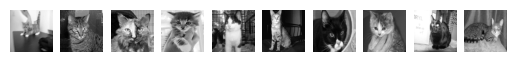

In [9]:
def visualize_and_resize_images(directory, num_images, new_size):
    # 获取指定目录中的所有图像文件
    images = [file for file in os.listdir(directory) if file.endswith(('.png', '.jpg', '.jpeg'))]

    # 遍历前num_images个图像文件
    for i, img_name in enumerate(images[:num_images]):
        img_path = os.path.join(directory, img_name)  # 拼接图像路径
        
        # 打开图像并调整大小
        img = Image.open(img_path)
        img = img.convert('L')
        img_resized = img.resize(new_size)
        

        # 可视化图像
        plt.subplot(1, num_images,i + 1)
        plt.imshow(img_resized,cmap='gray')
        plt.axis('off')  # 关闭坐标轴

    plt.show()  # 显示所有图像

# 使用示例
visualize_and_resize_images(train_dir, num_images=10, new_size=(128, 128))

In [11]:
# Count dataset size
def count_numbers_of_photo (directory):
    # 获取指定目录中的所有图像文件
    images = [file for file in os.listdir(directory) if file.endswith(('.png', '.jpg', '.jpeg'))]

    num_images = len(images)
    return num_images  # 返回图像数量
    
    print(f"Number of images: {num_images}")  # 打印图像数量

In [13]:
count_numbers_of_photo(train_dir)

25000

In [20]:
count_numbers_of_photo(test_dir)

12500

In [23]:
# Preprocess images by converting to grayscale and resizing
new_size=(128, 128)

def preprocess(directory, new_size):
    images_processed = []
    
    # 获取指定目录中的所有图像文件
    images = [file for file in os.listdir(directory) if file.endswith(('.png', '.jpg', '.jpeg'))]
        
    for img_name in images:  # 遍历images中的图像文件名
        img_path = os.path.join(directory, img_name)  # 构建图像路径
        img = Image.open(img_path)  # 打开图像
        img = img.convert('L')  # 转换为灰度图
        img_resized = img.resize(new_size)  # 调整图像大小
                
        img_array = np.array(img_resized) / 255.0  # 将图像归一化到[0, 1]范围
                
        images_processed.append(img_array)  # 保存处理后的图像数组
    
    dataset = np.array(images_processed)  # 将处理后的图像数组转换为numpy数组
    
    print(images_processed[:10])
    print(dataset[:10])
    
    return dataset

# 调用函数进行图像预处理
preprocessed_dataset = preprocess(train_dir, new_size)

[array([[0.65882353, 0.67843137, 0.68235294, ..., 0.82352941, 0.81176471,
        0.8       ],
       [0.65882353, 0.67843137, 0.68235294, ..., 0.82745098, 0.81568627,
        0.80784314],
       [0.65882353, 0.67843137, 0.68235294, ..., 0.83137255, 0.81960784,
        0.81176471],
       ...,
       [0.49411765, 0.50196078, 0.50588235, ..., 0.01176471, 0.01176471,
        0.00784314],
       [0.49411765, 0.49803922, 0.50588235, ..., 0.01176471, 0.01176471,
        0.01176471],
       [0.48235294, 0.49019608, 0.50196078, ..., 0.00784314, 0.00784314,
        0.00784314]]), array([[0.16862745, 0.17254902, 0.16862745, ..., 0.62745098, 0.77254902,
        0.76470588],
       [0.16470588, 0.16078431, 0.15686275, ..., 0.61960784, 0.74117647,
        0.76078431],
       [0.15686275, 0.14117647, 0.14117647, ..., 0.61568627, 0.71764706,
        0.75686275],
       ...,
       [0.08235294, 0.07058824, 0.07058824, ..., 0.18823529, 0.22745098,
        0.12941176],
       [0.10588235, 0.08235294, 0

In [25]:
# train
train_dataset = preprocess(train_dir, new_size)

[array([[0.65882353, 0.67843137, 0.68235294, ..., 0.82352941, 0.81176471,
        0.8       ],
       [0.65882353, 0.67843137, 0.68235294, ..., 0.82745098, 0.81568627,
        0.80784314],
       [0.65882353, 0.67843137, 0.68235294, ..., 0.83137255, 0.81960784,
        0.81176471],
       ...,
       [0.49411765, 0.50196078, 0.50588235, ..., 0.01176471, 0.01176471,
        0.00784314],
       [0.49411765, 0.49803922, 0.50588235, ..., 0.01176471, 0.01176471,
        0.01176471],
       [0.48235294, 0.49019608, 0.50196078, ..., 0.00784314, 0.00784314,
        0.00784314]]), array([[0.16862745, 0.17254902, 0.16862745, ..., 0.62745098, 0.77254902,
        0.76470588],
       [0.16470588, 0.16078431, 0.15686275, ..., 0.61960784, 0.74117647,
        0.76078431],
       [0.15686275, 0.14117647, 0.14117647, ..., 0.61568627, 0.71764706,
        0.75686275],
       ...,
       [0.08235294, 0.07058824, 0.07058824, ..., 0.18823529, 0.22745098,
        0.12941176],
       [0.10588235, 0.08235294, 0

In [26]:
# test
test_dataset = preprocess(test_dir, new_size)

[array([[0.23921569, 0.23137255, 0.21568627, ..., 0.42352941, 0.45882353,
        0.36470588],
       [0.23137255, 0.23137255, 0.22352941, ..., 0.42352941, 0.45882353,
        0.36470588],
       [0.22352941, 0.22352941, 0.22745098, ..., 0.41568627, 0.45098039,
        0.37254902],
       ...,
       [0.74901961, 0.76470588, 0.76078431, ..., 0.70588235, 0.59215686,
        0.57647059],
       [0.70980392, 0.74117647, 0.76078431, ..., 0.57254902, 0.49019608,
        0.4745098 ],
       [0.67843137, 0.72941176, 0.74509804, ..., 0.69803922, 0.55294118,
        0.36862745]]), array([[0.03529412, 0.03529412, 0.03529412, ..., 0.10588235, 0.11764706,
        0.10588235],
       [0.03529412, 0.03529412, 0.03529412, ..., 0.10196078, 0.10588235,
        0.10588235],
       [0.03529412, 0.03137255, 0.03137255, ..., 0.11764706, 0.12156863,
        0.09803922],
       ...,
       [0.25098039, 0.20392157, 0.22352941, ..., 0.28235294, 0.30196078,
        0.31372549],
       [0.22352941, 0.2       , 0

In [27]:
train_dataset

array([[[0.65882353, 0.67843137, 0.68235294, ..., 0.82352941,
         0.81176471, 0.8       ],
        [0.65882353, 0.67843137, 0.68235294, ..., 0.82745098,
         0.81568627, 0.80784314],
        [0.65882353, 0.67843137, 0.68235294, ..., 0.83137255,
         0.81960784, 0.81176471],
        ...,
        [0.49411765, 0.50196078, 0.50588235, ..., 0.01176471,
         0.01176471, 0.00784314],
        [0.49411765, 0.49803922, 0.50588235, ..., 0.01176471,
         0.01176471, 0.01176471],
        [0.48235294, 0.49019608, 0.50196078, ..., 0.00784314,
         0.00784314, 0.00784314]],

       [[0.16862745, 0.17254902, 0.16862745, ..., 0.62745098,
         0.77254902, 0.76470588],
        [0.16470588, 0.16078431, 0.15686275, ..., 0.61960784,
         0.74117647, 0.76078431],
        [0.15686275, 0.14117647, 0.14117647, ..., 0.61568627,
         0.71764706, 0.75686275],
        ...,
        [0.08235294, 0.07058824, 0.07058824, ..., 0.18823529,
         0.22745098, 0.12941176],
        [0.1

In [28]:
# extract class tags
def extract_tags(input_dir):
    results = []
    
    # 获取指定目录中的所有图像文件
    images = [file for file in os.listdir(input_dir) if file.endswith(('.png', '.jpg', '.jpeg'))]
        
    for img_path in images:
        if 'dog' in img_path.lower():
            results.append(('dog', img_path))
        elif 'cat' in img_path.lower():
            results.append(('cat', img_path))
        else:
            results.append(('unknown', img_path))  # Si no es identificable
        
    return results

In [29]:
train_labels = extract_tags(train_dir)

In [30]:
for label, img_path in train_labels[:10]:
    print(f"Image: {img_path}, Label: {label}")

Image: cat.0.jpg, Label: cat
Image: cat.1.jpg, Label: cat
Image: cat.10.jpg, Label: cat
Image: cat.100.jpg, Label: cat
Image: cat.1000.jpg, Label: cat
Image: cat.10000.jpg, Label: cat
Image: cat.10001.jpg, Label: cat
Image: cat.10002.jpg, Label: cat
Image: cat.10003.jpg, Label: cat
Image: cat.10004.jpg, Label: cat


In [31]:
print(train_labels[:10])

[('cat', 'cat.0.jpg'), ('cat', 'cat.1.jpg'), ('cat', 'cat.10.jpg'), ('cat', 'cat.100.jpg'), ('cat', 'cat.1000.jpg'), ('cat', 'cat.10000.jpg'), ('cat', 'cat.10001.jpg'), ('cat', 'cat.10002.jpg'), ('cat', 'cat.10003.jpg'), ('cat', 'cat.10004.jpg')]


In [39]:
# Building Model
train_binary = np.array([1 if label == 'dog' else 0 for label, _ in train_labels])

train_dataset = np.expand_dims(train_dataset, axis=-1)

# Train split
X_train, X_temp, y_train, y_temp = train_test_split(train_dataset, train_binary, test_size=0.2, random_state=42)

# Validation-Test Split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [59]:
# Create Model 创建并构建一个卷积神经网络（CNN）模型
model = Sequential()

# 使用 Input 层定义输入形状
model.add(Input(shape=(128, 128, 1)))

# Layer 1: Convolution+Max Pooling
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 2: Convolution+Max Pooling
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 3: Convolution+Max Pooling
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer for binary classification
model.add(Dense(1, activation='sigmoid'))

In [60]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [61]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 150ms/step - accuracy: 0.5973 - loss: 0.6674 - val_accuracy: 0.7212 - val_loss: 0.5357
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 162ms/step - accuracy: 0.7720 - loss: 0.4807 - val_accuracy: 0.8064 - val_loss: 0.4272
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.8197 - loss: 0.3946 - val_accuracy: 0.8212 - val_loss: 0.3939
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.8496 - loss: 0.3416 - val_accuracy: 0.8184 - val_loss: 0.4010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.8904 - loss: 0.2584 - val_accuracy: 0.8124 - val_loss: 0.4577
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.9335 - loss: 0.1722 - val_accuracy: 0.8380 - val_loss: 0.4243
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 167ms/step - accuracy: 0.9642 - loss: 0.1005 - val_accuracy: 0.8184 - val_loss: 0.5465
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.9818 - los

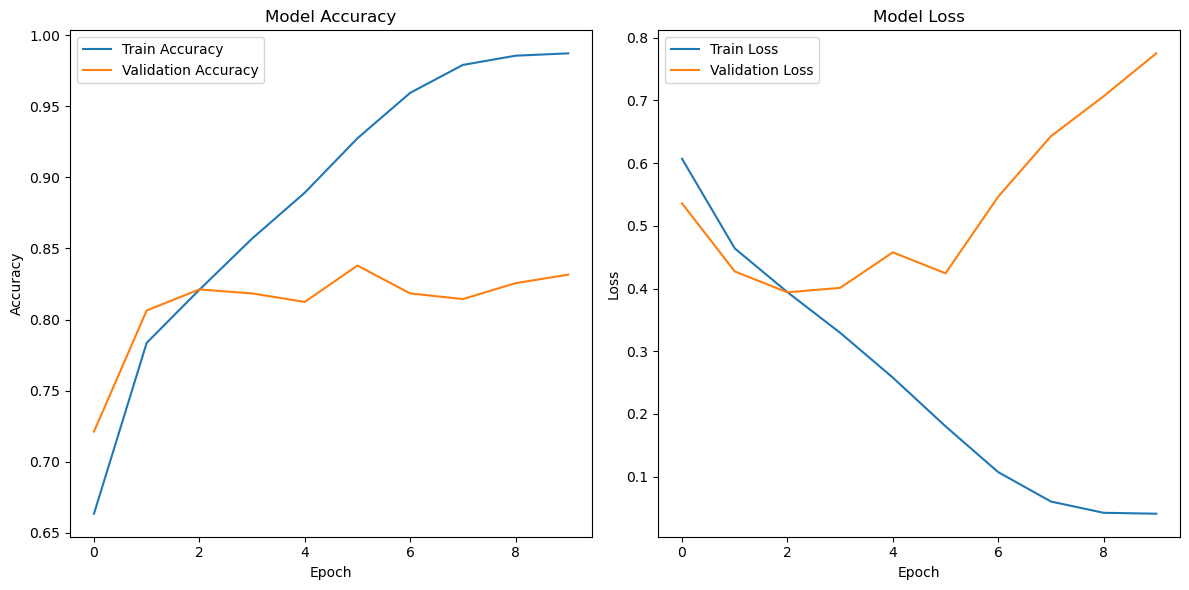

In [62]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [63]:
# Model Evaluation
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Accuracy: {accuracy:.4f}')
print(f'Loss: {loss:.4f}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8311 - loss: 0.7373
Accuracy: 0.8316
Loss: 0.7750


In [64]:
# Evaluat on Test Set
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy:.4f}')
print(f'Loss: {loss:.4f}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8287 - loss: 0.8428
Accuracy: 0.8148
Loss: 0.9130


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


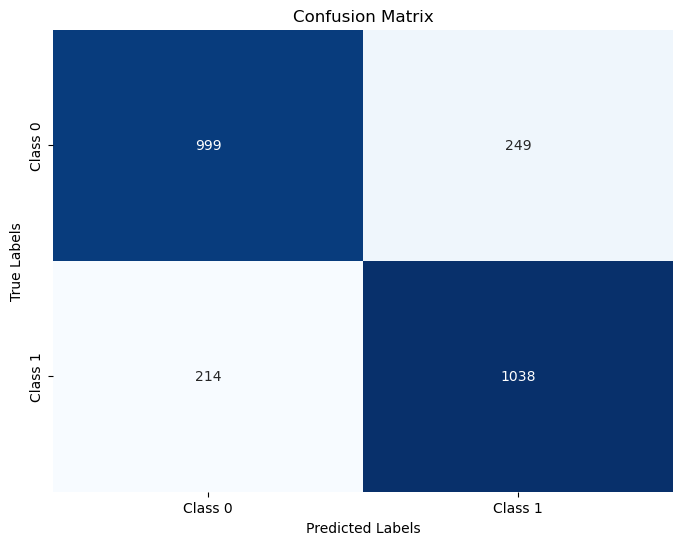

In [65]:
# Confusion Matrix
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# few random predictions
num_samples = 15  # Number of samples to display
random_indices = np.random.choice(len(X_test), num_samples, replace=False)
plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(X_test[idx].reshape(128, 128), cmap='gray')  # Reshape for display and use grayscale
    true_label = 'dog' if y_test[idx] == 1 else 'cat'  # True label
    pred_label = 'dog' if y_pred[idx][0] == 1 else 'cat'  # Predicted label
    plt.title(f'True: {true_label}\nPred: {pred_label}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [69]:
# 保存模型到文件
model.save("D:/Program/AI/cat_vs_dog..keras")  # 你可以指定任何你想要的文件名

In [ ]:
#######

In [ ]:
#尝试4层神经网络

In [41]:
# Create Model 创建并构建一个卷积神经网络（CNN）模型
model = Sequential()

# 使用 Input 层定义输入形状
model.add(Input(shape=(128, 128, 1)))

# Layer 1: Convolution+Max Pooling
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 2: Convolution+Max Pooling
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 3: Convolution+Max Pooling
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 4: Convolution+Max Pooling
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer for binary classification
model.add(Dense(1, activation='sigmoid'))

In [43]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [45]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 174ms/step - accuracy: 0.5599 - loss: 0.6807 - val_accuracy: 0.6832 - val_loss: 0.5907
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.7027 - loss: 0.5648 - val_accuracy: 0.7456 - val_loss: 0.5045
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 183ms/step - accuracy: 0.7978 - loss: 0.4377 - val_accuracy: 0.7988 - val_loss: 0.4246
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 180ms/step - accuracy: 0.8373 - loss: 0.3654 - val_accuracy: 0.8512 - val_loss: 0.3381
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.8768 - loss: 0.2855 - val_accuracy: 0.8544 - val_loss: 0.3246
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 178ms/step - accuracy: 0.9063 - loss: 0.2303 - val_accuracy: 0.8628 - val_loss: 0.3193
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 177ms/step - accuracy: 0.9286 - loss: 0.1747 - val_accuracy: 0.8472 - val_loss: 0.3812
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 118s 188ms/step - accuracy: 0.9548 -

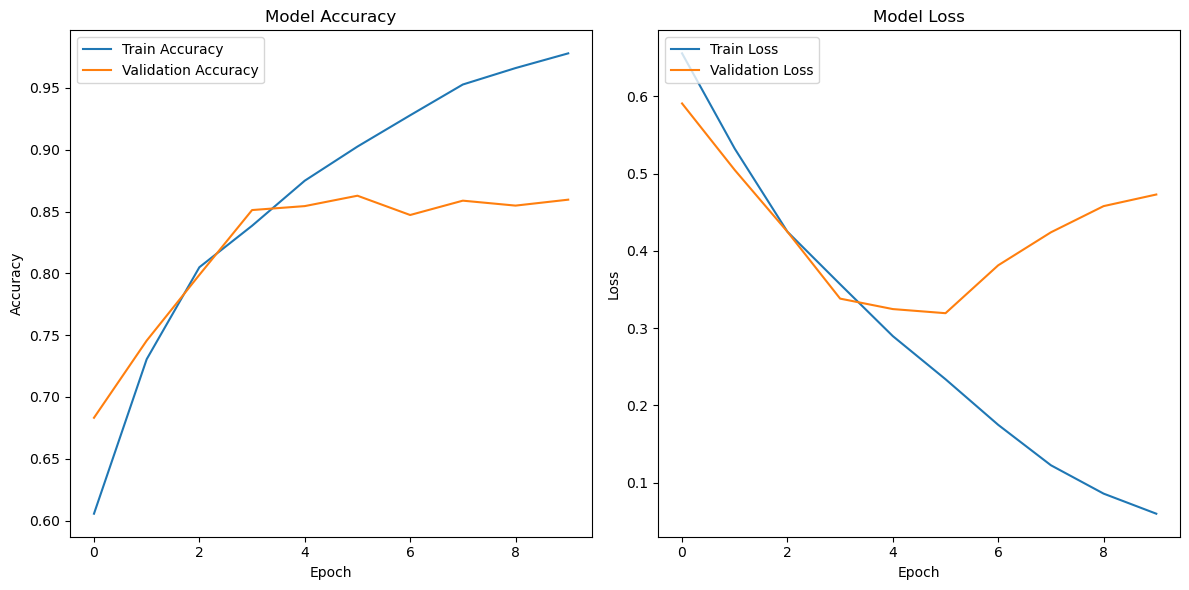

In [47]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [49]:
# Model Evaluation
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Accuracy: {accuracy:.4f}')
print(f'Loss: {loss:.4f}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8598 - loss: 0.4329
Accuracy: 0.8596
Loss: 0.4728


In [51]:
# Evaluat on Test Set
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy:.4f}')
print(f'Loss: {loss:.4f}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8785 - loss: 0.4568
Accuracy: 0.8668
Loss: 0.4727


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step


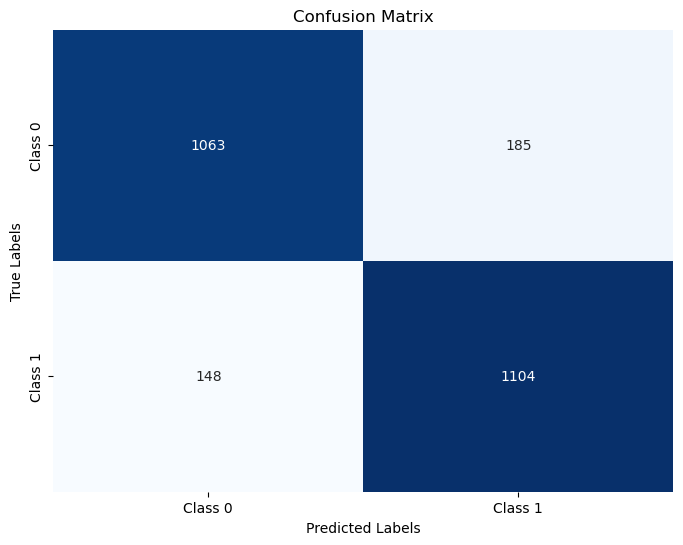

In [53]:
# Confusion Matrix
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

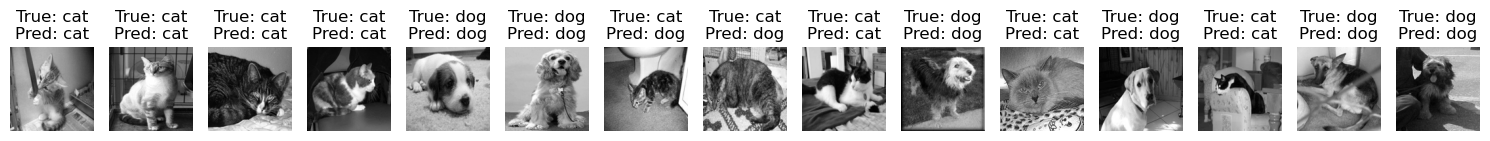

In [55]:
# few random predictions
num_samples = 15  # Number of samples to display
random_indices = np.random.choice(len(X_test), num_samples, replace=False)
plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(X_test[idx].reshape(128, 128), cmap='gray')  # Reshape for display and use grayscale
    true_label = 'dog' if y_test[idx] == 1 else 'cat'  # True label
    pred_label = 'dog' if y_pred[idx][0] == 1 else 'cat'  # Predicted label
    plt.title(f'True: {true_label}\nPred: {pred_label}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [57]:
# 保存模型到文件
model.save("D:/Program/AI/cat_vs_dog_new.keras")  # 你可以指定任何你想要的文件名